# Task 3: Cognitive load and the data-ink ratio

**CLO1:** how the brain processes visual information.

Plan: build the worst bar chart I can of `car_crashes.csv`, count what's in it, strip it back one step at a time, chunk it down to four things, then go too far on purpose and find where to stop. Last bit uses `tips.csv` to show a case where *adding* ink helps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

cc = pd.read_csv("car_crashes.csv")
cc_sorted = cc.sort_values("total", ascending=False).reset_index(drop=True)
print(cc.shape, "| missing values:", int(cc.isna().sum().sum()))
print(cc[["total"]].describe().T.round(2))

(51, 8) | missing values: 0
       count   mean   std  min    25%   50%   75%   max
total   51.0  15.79  4.12  5.9  12.75  15.6  18.5  23.9


`total` is fatal collisions per billion miles driven, for each state plus DC. I'm only using `total`, so there's no mixing of units on one axis.

## Step 1: the overloaded chart (on purpose)
Everything the brief asked for: a different colour for every bar, all 51 labels rotated, heavy gridlines both ways, a thick box frame, a 51-entry legend, a drop shadow, and a title that just names the axes.

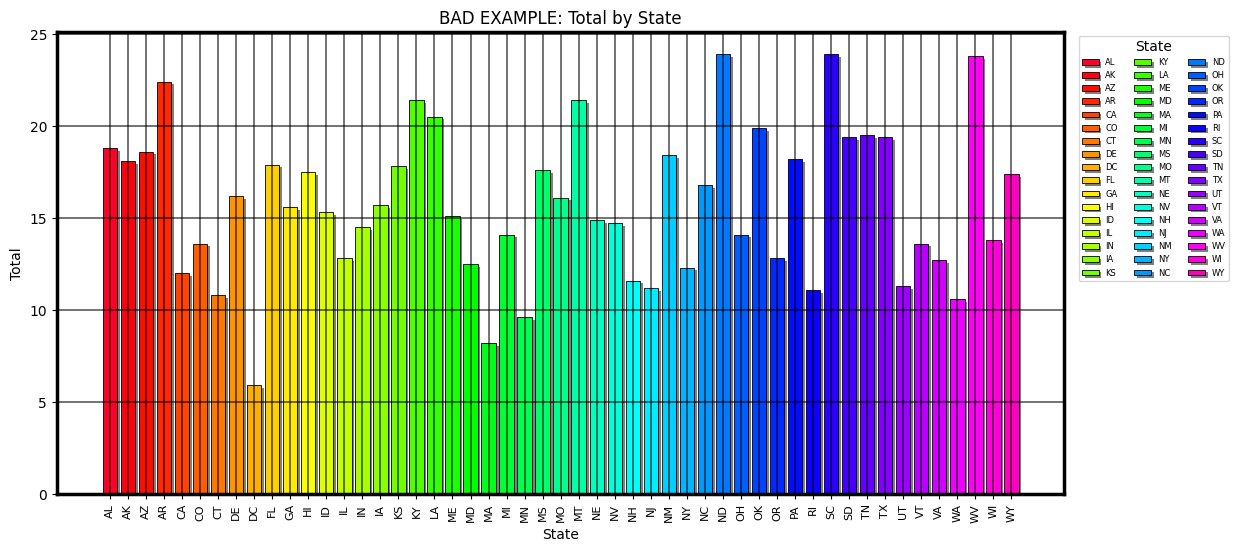

In [2]:
fig, ax = plt.subplots(figsize=(13, 6))
rainbow = plt.cm.gist_rainbow(np.linspace(0, 1, len(cc)))
bars = ax.bar(cc.abbrev, cc.total, color=rainbow, label=None, edgecolor="black", lw=0.6)
for b, ab in zip(bars, cc.abbrev):
    b.set_label(ab)
    b.set_path_effects([pe.withSimplePatchShadow(offset=(2, -2), shadow_rgbFace="black", alpha=0.5)])
ax.grid(True, axis="both", color="black", lw=1.1, alpha=0.7)
ax.set_axisbelow(False)
for side in ax.spines.values():
    side.set_linewidth(2.5)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_xlabel("State")
ax.set_ylabel("Total")
ax.legend(ncol=3, fontsize=6, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="State")
ax.set_title("BAD EXAMPLE: Total by State")
fig.savefig("t3_bad_overloaded.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 2: count the load

Every element, and what kind of load it is:

| Element | Load | Why |
|---|---|---|
| 51 bar heights | **intrinsic** | this *is* the data; 51 numbers is simply a lot |
| 51 state names on the x-axis | **intrinsic** | the reader needs to know which bar is which state |
| y-axis tick labels and the y label | **germane** | they let the reader turn a height into a number |
| 51 different bar colours | **extraneous** | colour says nothing: the state name is already given on the x-axis |
| 51-entry legend | **extraneous** | repeats the x-axis, and forces colour-to-name lookups |
| Vertical gridlines (51) | **extraneous** | the bars already sit on those positions |
| Horizontal gridlines | **germane** (light) / **extraneous** (as heavy as this) | they help read heights, but these are as dark as the bars |
| Box frame, thick | **extraneous** | encloses nothing that needs enclosing |
| Drop shadow (51) | **extraneous** | pure decoration, and it blurs the bar tops |
| Rotated labels | **extraneous** | the reader has to tilt their head to read 51 words |
| Title "Total by State" | **extraneous** | repeats the axis names and makes no claim |

**Data-ink ratio, with the working.** I count marks I can point at. "Encodes a number" = a bar (its height is the number) or a y tick label (it's how you read the number).

In [3]:
yt = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= ax.get_ylim()[1]]
n_y = len(yt)
counts = {
    "bars (height = number)": 51,
    "y tick labels (read the number)": n_y,
    "x tick labels": 51, "x tick marks": 51, "y tick marks": n_y,
    "vertical gridlines": 51, "horizontal gridlines": n_y,
    "frame sides": 4,
    "legend swatches": 51, "legend text entries": 51,
    "drop shadows": 51,
    "axis labels": 2, "title": 1,
}
data_marks = counts["bars (height = number)"] + counts["y tick labels (read the number)"]
total_marks = sum(counts.values())
for k, v in counts.items():
    print(f"{v:4d}  {k}")
print(f"\nmarks that encode a number: 51 + {n_y} = {data_marks}")
print(f"total marks: {total_marks}")
print(f"data-ink ratio ~ {data_marks}/{total_marks} = {data_marks/total_marks:.2f}")

  51  bars (height = number)
   6  y tick labels (read the number)
  51  x tick labels
  51  x tick marks
   6  y tick marks
  51  vertical gridlines
   6  horizontal gridlines
   4  frame sides
  51  legend swatches
  51  legend text entries
  51  drop shadows
   2  axis labels
   1  title

marks that encode a number: 51 + 6 = 57
total marks: 382
data-ink ratio ~ 57/382 = 0.15


Roughly one mark in seven carries a number (57 of 382). That's an estimate, since I'm counting marks and not measuring ink (the shadows and thick frame would push the true ratio lower still). The other six in seven are decoration or repetition.

## Step 3: five panels, one removal each
My order is the suggested one. The first four panels are the same chart losing weight; the last one is the finished version.

Each caption says what went and what kind of load it was.

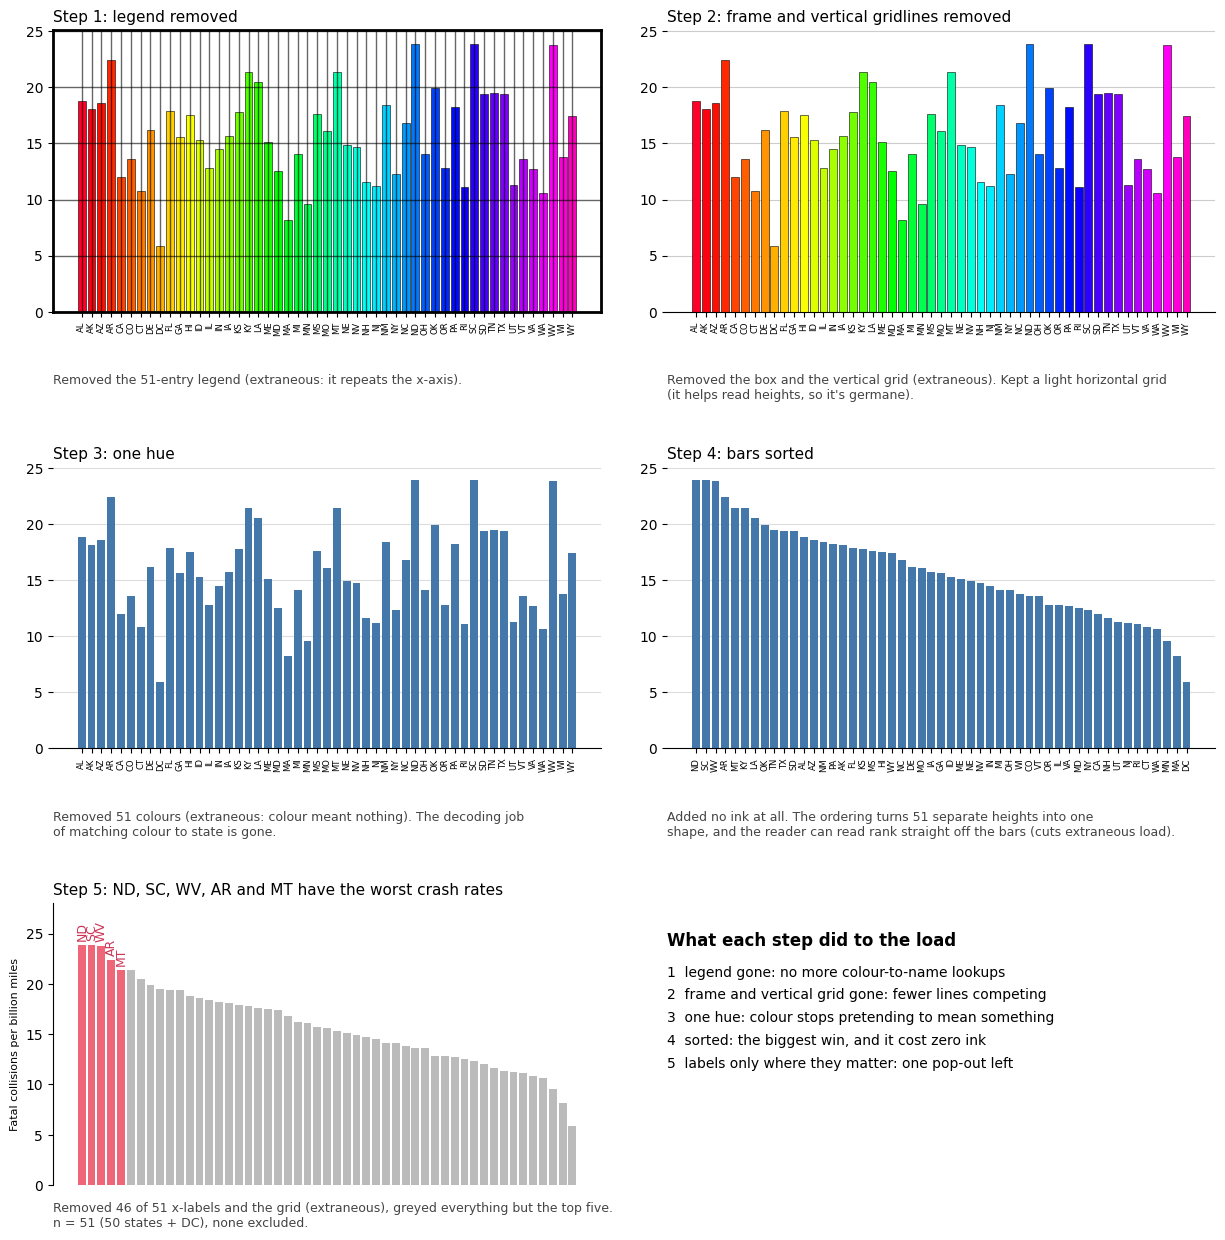

In [4]:
top5 = cc_sorted.head(5)
top5_names = ", ".join(top5.abbrev[:-1]) + " and " + top5.abbrev.iloc[-1]
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axs = axes.ravel()
GREY, ACCENT, BLUE = "#bbbbbb", "#ee6677", "#4477aa"

def caption(ax, text, y):
    ax.text(0, y, text, transform=ax.transAxes, va="top", fontsize=9, color="#444444")

# Panel 1: remove the legend
ax = axs[0]
ax.bar(cc.abbrev, cc.total, color=rainbow, edgecolor="black", lw=0.4)
ax.grid(True, color="black", lw=1.0, alpha=0.6)
ax.tick_params(axis="x", rotation=90, labelsize=6)
for s in ax.spines.values(): s.set_linewidth(2)
ax.set_title("Step 1: legend removed", loc="left", fontsize=11)
caption(ax, "Removed the 51-entry legend (extraneous: it repeats the x-axis).", -0.22)

# Panel 2: remove frame and vertical gridlines
ax = axs[1]
ax.bar(cc.abbrev, cc.total, color=rainbow, edgecolor="black", lw=0.4)
ax.grid(True, axis="y", color="#cccccc", lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=90, labelsize=6)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.set_title("Step 2: frame and vertical gridlines removed", loc="left", fontsize=11)
caption(ax, "Removed the box and the vertical grid (extraneous). Kept a light horizontal grid\n(it helps read heights, so it's germane).", -0.22)

# Panel 3: single hue
ax = axs[2]
ax.bar(cc.abbrev, cc.total, color=BLUE)
ax.grid(True, axis="y", color="#dddddd", lw=0.8); ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=90, labelsize=6)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.set_title("Step 3: one hue", loc="left", fontsize=11)
caption(ax, "Removed 51 colours (extraneous: colour meant nothing). The decoding job\nof matching colour to state is gone.", -0.22)

# Panel 4: sort
ax = axs[3]
ax.bar(cc_sorted.abbrev, cc_sorted.total, color=BLUE)
ax.grid(True, axis="y", color="#dddddd", lw=0.8); ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=90, labelsize=6)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.set_title("Step 4: bars sorted", loc="left", fontsize=11)
caption(ax, "Added no ink at all. The ordering turns 51 separate heights into one\nshape, and the reader can read rank straight off the bars (cuts extraneous load).", -0.22)

# Panel 5: label only what matters, one pop-out
ax = axs[4]
cols = [ACCENT if i < 5 else GREY for i in range(len(cc_sorted))]
ax.bar(range(len(cc_sorted)), cc_sorted.total, color=cols)
for i in range(5):
    ax.text(i, cc_sorted.total[i] + 0.4, cc_sorted.abbrev[i], ha="center", va="bottom", rotation=90, fontsize=9, color="#cc3355")
ax.set_xticks([])
ax.set_ylim(0, 28)
for s in ("top", "right", "bottom"): ax.spines[s].set_visible(False)
ax.set_ylabel("Fatal collisions per billion miles", fontsize=8)
ax.set_title(f"Step 5: {top5_names} have the worst crash rates", loc="left", fontsize=11)
caption(ax, "Removed 46 of 51 x-labels and the grid (extraneous), greyed everything but the top five.\nn = 51 (50 states + DC), none excluded.", -0.06)

# 6th cell: summary text, not a chart
ax = axs[5]
ax.axis("off")
ax.text(0, 0.9, "What each step did to the load", fontsize=12, fontweight="bold", va="top")
ax.text(0, 0.78, "1  legend gone: no more colour-to-name lookups\n"
                 "2  frame and vertical grid gone: fewer lines competing\n"
                 "3  one hue: colour stops pretending to mean something\n"
                 "4  sorted: the biggest win, and it cost zero ink\n"
                 "5  labels only where they matter: one pop-out left",
        fontsize=10, va="top", linespacing=1.8)
fig.subplots_adjust(hspace=0.55, wspace=0.12)
fig.savefig("t3_five_steps.png", dpi=300, bbox_inches="tight")
plt.show()

**What I noticed.** Step 4, sorting, did more for me than any other step. It added no ink: the same 51 bars, same colour, same axes. Before it, to find the worst state I had to scan 51 heights. After it, the worst state is the first bar and the pattern (a few very bad states, then a slow slope) is visible as a shape. That's a good example of extraneous load that isn't ink at all: the order itself was the clutter.

## Step 4: respect the 4 +/- 1 limit
I chunked the 51 states into the four US Census regions: Northeast, Midwest, South, West. That's exactly four things to hold. Bars show each region's average, and the grey dots are the individual states, so the spread inside a region is still there. I'm labelling one state only (the overall worst).

Gestalt principle doing the grouping: **proximity** (each region's dots sit on its own row).

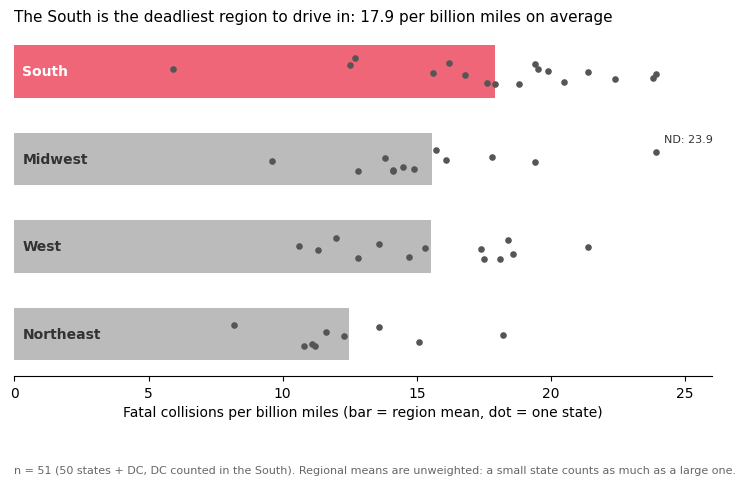

region
Northeast    12.46
West         15.52
Midwest      15.56
South        17.93
Name: total, dtype: float64


In [5]:
REGION = {}
for r, states in {
    "Northeast": "CT ME MA NH RI VT NJ NY PA",
    "Midwest": "IL IN MI OH WI IA KS MN MO NE ND SD",
    "South": "DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX",
    "West": "AZ CO ID MT NV NM UT WY AK CA HI OR WA",
}.items():
    for s in states.split():
        REGION[s] = r
cc["region"] = cc.abbrev.map(REGION)
assert cc.region.notna().all(), cc[cc.region.isna()]
reg = cc.groupby("region").total.mean().sort_values()
worst = cc.loc[cc.total.idxmax()]
top_region = reg.index[-1]

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, r in enumerate(reg.index):
    ax.barh(i, reg[r], color=ACCENT if r == top_region else GREY, height=0.6, zorder=1)
    states = cc[cc.region == r]
    rng = np.random.default_rng(3)
    ax.scatter(states.total, i + rng.uniform(-0.17, 0.17, len(states)), s=14, color="#555555", zorder=2)
    ax.text(0.3, i, r, va="center", fontsize=10, color="white" if r == top_region else "#333333", fontweight="bold")
ax.annotate(f"{worst.abbrev}: {worst.total}", (worst.total, list(reg.index).index(REGION[worst.abbrev])),
            xytext=(6, 12), textcoords="offset points", fontsize=8, color="#333333")
ax.set_yticks([])
ax.set_xlim(0, 26)
ax.set_xlabel("Fatal collisions per billion miles (bar = region mean, dot = one state)")
ax.set_title(f"The {top_region} is the deadliest region to drive in: {reg[top_region]:.1f} per billion miles on average", loc="left", fontsize=11)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.text(0, -0.28, "n = 51 (50 states + DC, DC counted in the South). Regional means are unweighted: a small state counts as much as a large one.",
        transform=ax.transAxes, fontsize=8, color="#666666")
fig.savefig("t3_four_chunks.png", dpi=300, bbox_inches="tight")
plt.show()
print(reg.round(2))

**What this chunking costs.** Every chunking hides something, and here it hides three things. First, **which states** are good or bad, except for the one I labelled. Second, **regions aren't uniform**: the dots show some overlap, so "South is worst" does not mean every southern state is worse than every western one. Third, the unweighted mean treats Wyoming and California as equals, so it isn't "the average driver's risk". I chose regions over "top five plus other 46" because the second version throws away the whole middle of the distribution, and I'd rather lose the names than the shape.

## Step 5: over-strip it
Same sorted bars, but I removed the axis labels, tick values, units and anything else that says what these bars are.

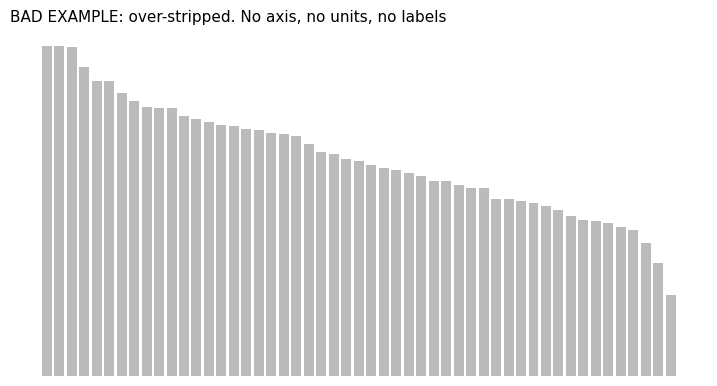

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(cc_sorted)), cc_sorted.total, color=GREY)
ax.axis("off")
ax.set_title("BAD EXAMPLE: over-stripped. No axis, no units, no labels", loc="left", fontsize=11)
fig.savefig("t3_bad_overstripped.png", dpi=300, bbox_inches="tight")
plt.show()

**Why max data-ink isn't the goal.** This chart has the highest data-ink ratio I've drawn: every mark left is a bar. But I can't tell what it measures, whether the tallest is twice the shortest (no axis, though the bars do start at zero), or which bar is a state I care about. The ratio went up and the chart got worse, because I removed ink that carried *context*, and context is information.

**Stopping rule, one sentence:** stop removing ink the moment a reader couldn't answer the chart's question without asking me something.

## The question: a chart where *adding* ink lowers cognitive load (`tips.csv`)
Tip against total bill. Left: just the dots. Right: the same dots plus one reference line at a 15% tip. In the left chart, deciding whether any dot is a "good" tip means mentally dividing tip by bill. The line does that division for all 244 dots at once.

Pop-out in the right chart: the line (strong colour). Dots stay grey. The line is directly labelled, so colour isn't the only carrier.

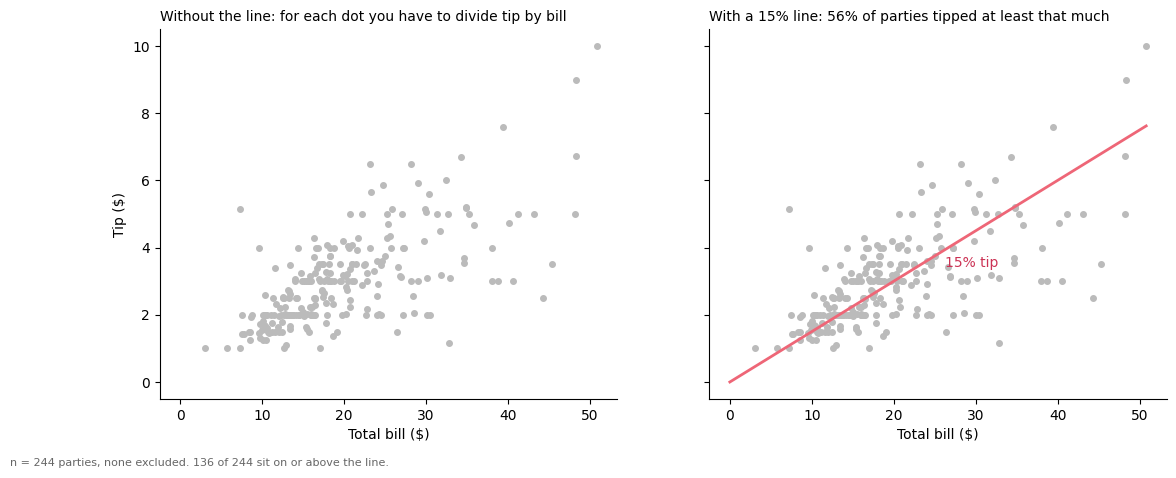

In [7]:
tips = pd.read_csv("tips.csv")
tips["pct"] = tips.tip / tips.total_bill * 100
at_least_15 = (tips.pct >= 15).sum()
share = at_least_15 / len(tips) * 100

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, sharex=True)
for ax_ in (a, b):
    ax_.scatter(tips.total_bill, tips.tip, s=16, color=GREY)
    ax_.set_xlabel("Total bill ($)")
    for s in ("top", "right"): ax_.spines[s].set_visible(False)
a.set_ylabel("Tip ($)")
a.set_title("Without the line: for each dot you have to divide tip by bill", loc="left", fontsize=10)
xs = np.array([0, tips.total_bill.max()])
b.plot(xs, 0.15 * xs, color=ACCENT, lw=2)
b.text(xs[1] * 0.58, 0.15 * xs[1] * 0.58 - 1.0, "15% tip", color="#cc3355", fontsize=10, ha="center")
b.set_title(f"With a 15% line: {share:.0f}% of parties tipped at least that much", loc="left", fontsize=10)
fig.text(0.01, -0.03, f"n = {len(tips)} parties, none excluded. {at_least_15} of {len(tips)} sit on or above the line.",
         fontsize=8, color="#666666")
fig.savefig("t3_tips_reference_line.png", dpi=300, bbox_inches="tight")
plt.show()

**Why this is a heuristic and not a rule.** The 15% line doesn't encode any of the 244 data points. By the data-ink formula it's pure non-data ink and should go. But it carries a calculation the reader would otherwise run in their head 244 times, and working memory is the scarce thing. So what I'm minimising is *the reader's effort*, and ink is only a rough stand-in for it. Most of the time less ink means less effort, which is why the rule is useful. Here it points the wrong way.